# **Design of Experiments for Binder Jet Printing**

### 1 | Import Libraries and Data

In [39]:
# data-handling
import pandas as pd
import numpy as np
import re
from copy import deepcopy

# models for MANOVA
from statsmodels.multivariate import manova
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# visualisation
import matplotlib.pyplot as plt
WEB_COLOR = "#085E57"     ### core colour from my personal webpage, defined for convenience

In [40]:
# read data
df = pd.read_csv('data_binder_jetting.csv', index_col='batch_id')

# display first 5 rows to check data read
df.head()

,binder_saturation_pct,particle_size_d50_um,binder_viscosity_cp,layer_thickness_um,cure_temp_c,cure_time_min,green_strength_mpa,print_density_pct
batch_id,,,,,,,,
BJ-001,68.8,21.3,22.6,99,164,47,1.02,67.6
BJ-002,68.2,29.2,21.3,82,156,42,1.04,66.7
BJ-003,64.2,41.2,10.9,120,158,54,0.57,57.3
BJ-004,82.7,34.6,22.0,140,197,92,2.78,53.7
BJ-005,59.3,31.3,22.0,81,157,27,0.30,66.2


### 2 | Check Correlation between Dependent Variables

In [41]:
# generate correlation and covariance matrices
corr = df[['green_strength_mpa', 'print_density_pct']].corr()          # correlation matrix
cov  = df[['green_strength_mpa', 'print_density_pct']].cov()           # covariance matrix

# display
print(f"Correlation:\n {corr} \n\nCovariance:\n {cov}")

Correlation:
                     green_strength_mpa  print_density_pct
green_strength_mpa            1.000000          -0.186179
print_density_pct            -0.186179           1.000000 

Covariance:
                     green_strength_mpa  print_density_pct
green_strength_mpa            1.040288          -0.736015
print_density_pct            -0.736015          15.023006


green_strength_mpa vs. print_density_pct, R2 score: 0.03466


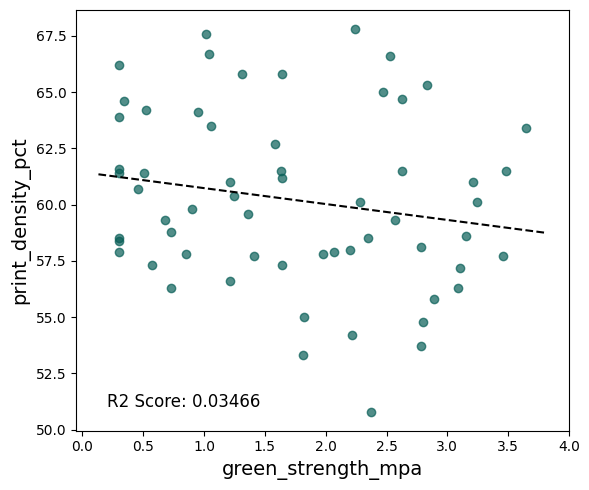

In [42]:
#######################################
#   RUN LINEAR REGRESSION
#######################################

# format data to enable parsing by LinearRegression model
df_gs = df['green_strength_mpa'].to_numpy().reshape(-1,1)
df_pd = df['print_density_pct'].to_numpy().reshape(-1,1)

# run linear regression and get R2 score
lin = LinearRegression().fit(df_gs, df_pd)
lin_r2 = lin.score(df_gs, df_pd)

# print R2 score
print(f"green_strength_mpa vs. print_density_pct, R2 score: {lin_r2:.5f}")



#######################################
#   VISUALISE RESULT
#######################################

# define chart area
fig, ax = plt.subplots(figsize=(6,5))

# plot data
ax.scatter(df['green_strength_mpa'], df['print_density_pct'], c=WEB_COLOR, alpha=0.7)

# plot linear regression model
x1, x2 = ax.get_xlim()
x_range = np.linspace(x1, x2, 50).reshape(-1,1)
y_pred = lin.predict(x_range)

plt.plot(x_range, y_pred, c='black', linestyle='--')

# annotations
ax.set_xlabel('green_strength_mpa', fontsize=14)
ax.set_ylabel('print_density_pct', fontsize=14)

ax.annotate(xy=(0.2, 51), text=f"R2 Score: {lin_r2:.5f}", fontsize=12)

# display
fig.tight_layout()

### 3 | MODEL 1: Multivariate Analysis of Variance (MANOVA)

##### 3.1 | Define Variables and MANOVA Experiment

In [43]:
#######################################
#   VARIABLES
#######################################

### individual dependent variables
dvs = ['green_strength_mpa', 'print_density_pct']

### individual independent variables
ivs = [
    'binder_saturation_pct', 'particle_size_d50_um', 'binder_viscosity_cp',
    'layer_thickness_um', 'cure_temp_c', 'cure_time_min',
]

### individual independent variables and all possible combinations
ivs_comb = [
    'binder_saturation_pct', 'particle_size_d50_um', 'binder_viscosity_cp',
    'layer_thickness_um', 'cure_temp_c', 'cure_time_min',
    'binder_saturation_pct:particle_size_d50_um', 'binder_saturation_pct:binder_viscosity_cp', 'binder_saturation_pct:layer_thickness_um', 
    'binder_saturation_pct:cure_temp_c', 'binder_saturation_pct:cure_time_min',
    'particle_size_d50_um:binder_viscosity_cp','particle_size_d50_um:layer_thickness_um','particle_size_d50_um:cure_temp_c','particle_size_d50_um:cure_time_min',
    'binder_viscosity_cp:layer_thickness_um','binder_viscosity_cp:cure_temp_c','binder_viscosity_cp:cure_time_min',
    'layer_thickness_um:cure_temp_c','layer_thickness_um:cure_time_min',
    'cure_temp_c:cure_time_min',
]

In [44]:
def run_iterative_manova(data:pd.DataFrame, dependent_variables:list, independent_variables:list):
    '''
    Runs a single MANOVA experiment.

    Acts as a wrapper for the entire experiment for use in an iterative workflow.

    Returns the formula used and the results in a DataFrame object.
    '''   

    # -------------------   MODEL   -------------------

    # define formula for MANOVA (uses the Patsy package that statsmodels is built on)
    formula = " + ".join(dependent_variables) + " ~ " + " + ".join(independent_variables)

    # apply model
    res = manova.MANOVA.from_formula(formula, data=data)#.fit()


    # ----------   COLLECT AND FORMAT DATA   ----------

    # define empty DataFrame object, and populate 'ivs' column with all IVs and combinations used in the experiment
    df_manova = pd.DataFrame(columns=['ivs','main','Pr > F'])
    keys = res.mv_test().results.keys()

    # add to DataFrame
    df_manova['ivs'] = keys
    
    # populate the 'main' column (indicating whether a main feature or an interaction)
    main_tf = []
    
    for k in keys:
        # check for a ':' in the feature name (indicates interaction term) and append True/False
        if bool(re.search(':', k)) == True:
            main_tf.append(False)
        else:
            main_tf.append(True)

    # add to DataFrame
    df_manova['main'] = main_tf

    # for each feature, access the statistic table and pull out the p-value (here called: 'Pr > F')
    for index, row in df_manova.iterrows():
        stat_table = res.mv_test().results[row['ivs']]['stat']
        p_val = stat_table.loc["Pillai's trace"]["Pr > F"]
        
        # add to DataFrame
        df_manova.loc[index, 'Pr > F'] = p_val

    # sort DataFrame according to p=values so that the highest is first, re-index
    df_manova = df_manova.sort_values('Pr > F', ascending=False, ignore_index=True)


    return df_manova, formula

##### 3.2 | Run Iterative MANOVA Experiment to Remove Insignificant Features

In [45]:
flag = False        ### monitors if all insignificant variables have been removed
ivs_removed = []    ### monitors which main features have been removed


while flag == False:
    # run MANOVA experiment
    df_man, formula = run_iterative_manova(df, dvs, ivs_comb)

    # split into main features and interactions
    df_man_main = df_man[df_man["main"] == True]
    df_man_interaction = df_man[df_man["main"] == False]


    #######################################
    #   INTERACTIONS
    #######################################

    # remove interaction with worst p value, if any are above 0.05
    if df_man_interaction.iloc[0]['Pr > F'] > 0.05:
        least_significant = df_man_interaction.iloc[0]['ivs']

        # get index of value in 'ivs_comb' list and pop this
        to_pop = ivs_comb.index(least_significant)
        ivs_comb.pop(to_pop)

        # give user feedback
        print(f"{len(ivs_comb)} FEATURES REMAINING: removed interaction {least_significant}")
        
    else:
        # if all interactions meet the threshold of p < 0.05, terminate iterative experiment
        flag = True
        print("-------- Resolved --------\n")


    #######################################
    #   MAIN FEATURES
    #######################################

    # check whether each main feature is present in at least one interaction
    present_in_interactions = []     ### collects all IVs present in the interaction features
    
    # for each interaction, split the two IVs in each interaction and append to 'present_in_interactions'
    for x in ivs_comb:
        if bool(re.search(':', x)) == True:
            x1, x2 = x.split(':')
            present_in_interactions.append(x1)
            present_in_interactions.append(x2)

    # create a dictionary using 'present_in_interactions' to define keys
    # collapses any duplicate values in 'present_in_interactions' into a single key
    present_in_interactions_dict = list(dict.fromkeys(present_in_interactions))

    ivs_copy = deepcopy(ivs)     ### deepcopy variable to break link to original

    # for each main feature present in the interactions, pop this from the list of all main features
    # leaves only those main features present in no interactions
    for iv in present_in_interactions_dict:
        to_pop = ivs_copy.index(iv)
        ivs_copy.pop(to_pop)

    # for each main feature already removed, pop this from the list of all main features too
    # avoids attempts to remove the same feature twice
    for iv in ivs_removed:
        to_pop = ivs_copy.index(iv)
        ivs_copy.pop(to_pop)

    # for any main feature remaining in 'ivs_copy' (:. main features to be removed), remove if insignificant
    for iv in ivs_copy:
        # if main feature p-value above 0.05, get index in 'ivs_comb' and pop
        if df_man_main[df_man_main['ivs'] == iv]['Pr > F'].to_numpy()[0] > 0.05:
            to_pop = ivs_comb.index(iv)
            ivs_comb.pop(to_pop)

            # give user feedback
            print(f"{len(ivs_comb)} FEATURES REMAINING: removed main feature {iv}")

            # monitor main features removed by adding to 'ivs_removed'
            ivs_removed.append(iv)

# display final results and formula
print(formula, df_man)

20 FEATURES REMAINING: removed interaction binder_viscosity_cp:cure_temp_c
19 FEATURES REMAINING: removed interaction layer_thickness_um:cure_temp_c
18 FEATURES REMAINING: removed interaction particle_size_d50_um:binder_viscosity_cp
17 FEATURES REMAINING: removed interaction binder_saturation_pct:layer_thickness_um
16 FEATURES REMAINING: removed interaction layer_thickness_um:cure_time_min
15 FEATURES REMAINING: removed interaction particle_size_d50_um:cure_time_min
14 FEATURES REMAINING: removed interaction binder_saturation_pct:binder_viscosity_cp
13 FEATURES REMAINING: removed interaction binder_viscosity_cp:cure_time_min
12 FEATURES REMAINING: removed interaction particle_size_d50_um:cure_temp_c
11 FEATURES REMAINING: removed interaction binder_viscosity_cp:layer_thickness_um
10 FEATURES REMAINING: removed main feature binder_viscosity_cp
9 FEATURES REMAINING: removed interaction binder_saturation_pct:cure_temp_c
8 FEATURES REMAINING: removed interaction cure_temp_c:cure_time_min
7

##### 3.3 | Model and Visualise Results

In [46]:
#######################################
#   DEFINE VISUALISATION FUNCTIONS
#######################################

def plot_main(data:pd.DataFrame, feature:str, response:str):
    '''
    Plots a scatter chart of a single main feature against a response.
    '''
    # define chart area
    fig = plt.figure(figsize=(5,4))

    # plot data
    plt.scatter(x=data[feature], y=data[response], alpha=0.7, c=WEB_COLOR)
    
    # annotate
    plt.xlabel(feature)
    plt.ylabel(response)

    # format
    fig.tight_layout()
    

def plot_interaction(data:pd.DataFrame, model, feature1:str, feature2:str, response:str, constant_features:list=[]):
    '''
    Plots a contour plot of two features coloured by the response indicating their interation.
    '''
    # define chart area
    fig = plt.figure(figsize=(5,4))

    # define xlims and ylims
    x1, x2 = data[feature1].min(), data[feature1].max(),
    y1, y2 = data[feature2].min(), data[feature2].max(),

    # create sampling grid (25x25)
    x_range = np.linspace(x1, x2, 25)
    y_range = np.linspace(y1, y2, 25)
    X, Y = np.meshgrid(x_range, y_range)

    # create DataFrame indicating IV values at each sampling point
    grid = pd.DataFrame({
        feature1: X.ravel(),
        feature2: Y.ravel(),
    })

    # get mean values for constant features and add to the 'grid' DataFrame
    for ft in constant_features:
        grid[ft] = data[ft].mean()

    # predict the response at each combination of IV values
    Z = model.predict(grid).values.reshape(X.shape)

    # plot data
    plt.contourf(X, Y, Z, levels=50, cmap="viridis")
    plt.colorbar(label=response)

    # annotate
    plt.xlabel(feature1)
    plt.ylabel(feature2)

    # format
    fig.tight_layout()

##### *Green Strength Results*

In [47]:
#######################################
#   ORDINARY LEAST SQUARES MODELS
#######################################

# fit ordinary least squares (OLS) linear regression model for green strength using same predictor terms as `formula`
strength_model = smf.ols(
    "green_strength_mpa " + re.findall('(?=[~]).*', formula)[0],
    data=df
).fit()

print(f'-------- GREEN STRENGTH MODEL --------\n{strength_model.summary()}\n\n')

-------- GREEN STRENGTH MODEL --------
                            OLS Regression Results                            
Dep. Variable:     green_strength_mpa   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     137.6
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           2.98e-31
Time:                        11:40:46   Log-Likelihood:                 3.3403
No. Observations:                  60   AIC:                             9.319
Df Residuals:                      52   BIC:                             26.07
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

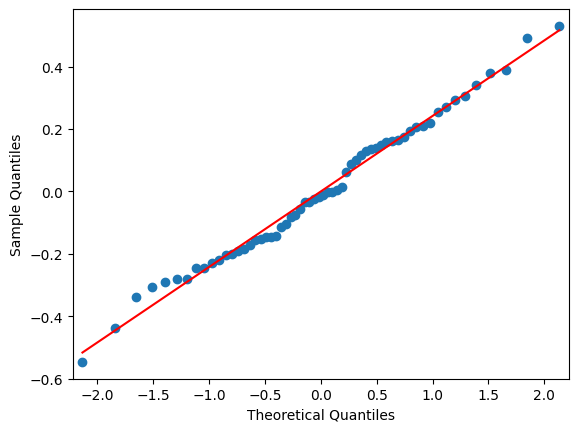

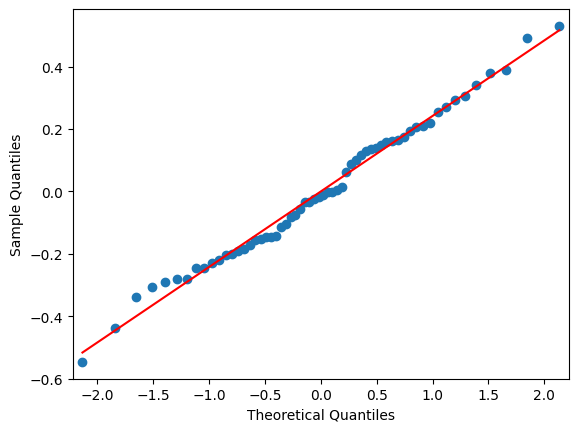

In [48]:
# check Q-Q plot for green strength
residuals = strength_model.resid 
fitted = strength_model.fittedvalues   

sm.qqplot(residuals, line='r')

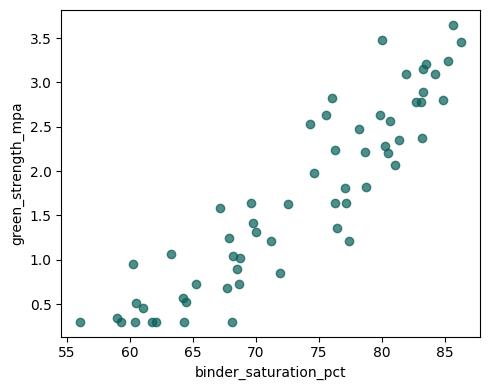

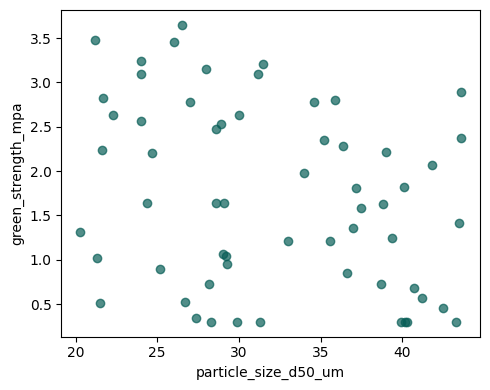

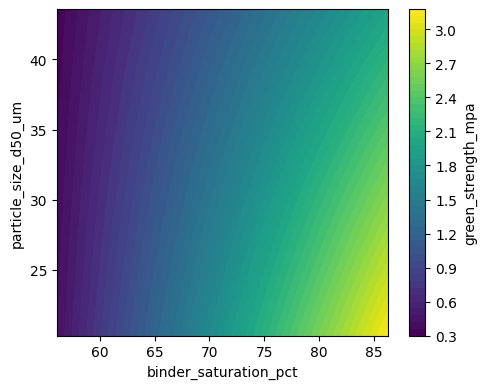

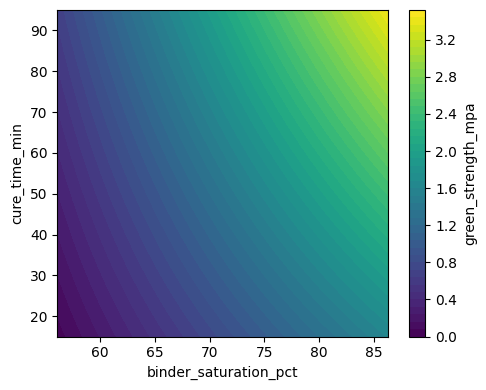

In [49]:
#######################################
#   GREEN STRENGTH VISUALISATIONS
#######################################

# -----------   SIGNIFICANT MAIN FEATURES   -----------

plot_main(
    df, 'binder_saturation_pct', 'green_strength_mpa'
)

plot_main(
    df, 'particle_size_d50_um', 'green_strength_mpa'
)


# -----------   SIGNIFICANT INTERACTIONS   ------------

plot_interaction(
    df, strength_model, 
    'binder_saturation_pct', 'particle_size_d50_um', 
    'green_strength_mpa',
    ['layer_thickness_um', 'cure_time_min']
)

plot_interaction(
    df, strength_model, 
    'binder_saturation_pct', 'cure_time_min', 
    'green_strength_mpa',
    ['layer_thickness_um', 'particle_size_d50_um']
)

##### *Print Density Model*

In [50]:
#######################################
#   ORDINARY LEAST SQUARES MODELS
#######################################

# fit ordinary least squares (OLS) linear regression model for print density using same predictor terms as `formula`
density_model = smf.ols(
    "print_density_pct " + re.findall('(?=[~]).*', formula)[0],
    data=df
).fit()

print(f'-------- PRINT DENSITY MODEL --------\n{density_model.summary()}\n\n')

-------- PRINT DENSITY MODEL --------
                            OLS Regression Results                            
Dep. Variable:      print_density_pct   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     112.6
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           3.97e-29
Time:                        11:40:46   Log-Likelihood:                -82.441
No. Observations:                  60   AIC:                             180.9
Df Residuals:                      52   BIC:                             197.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

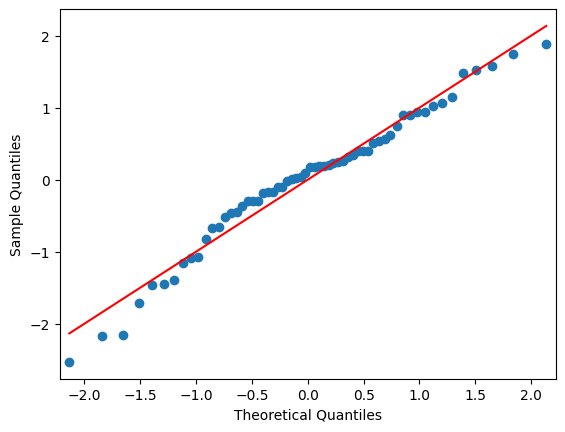

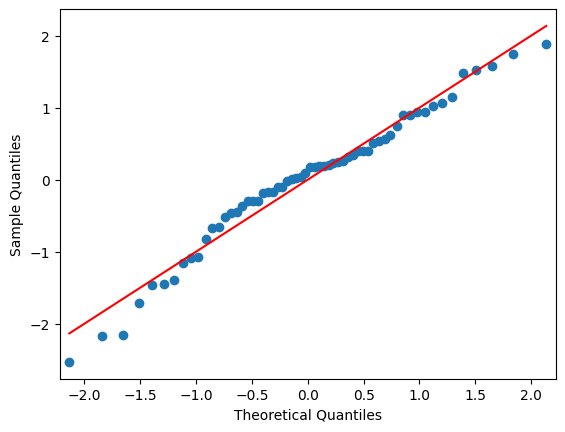

In [51]:
# check Q-Q plot for particle density
residuals = density_model.resid 
fitted = density_model.fittedvalues   

sm.qqplot(residuals, line='r')

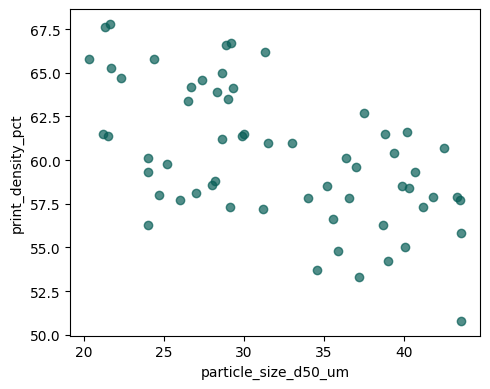

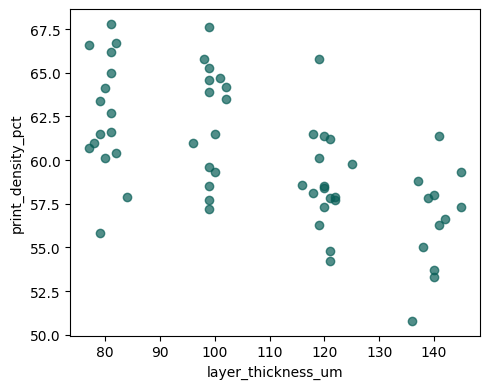

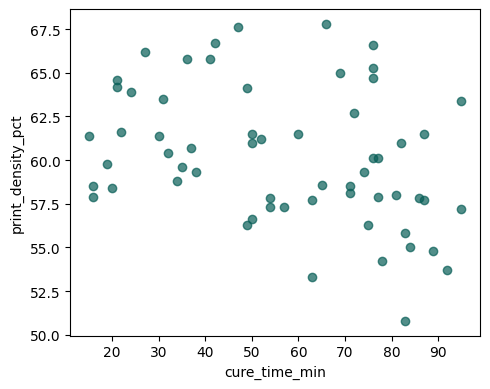

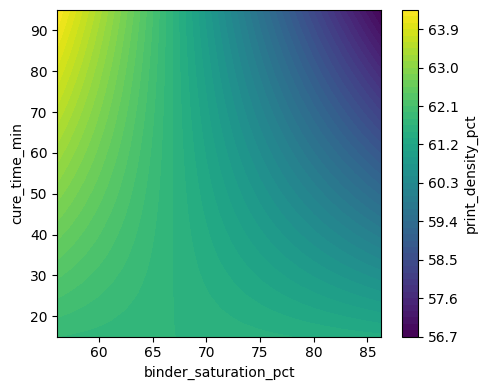

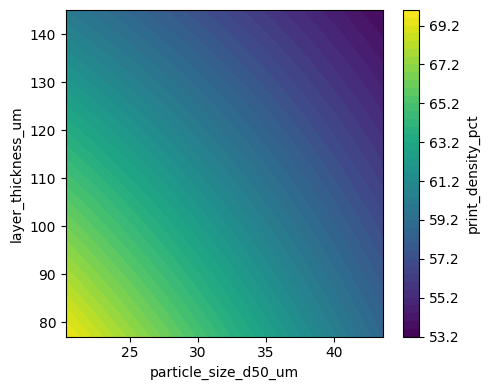

In [52]:
#######################################
#   PRINT DENSITY VISUALISATIONS
#######################################

# -----------   SIGNIFICANT MAIN FEATURES   -----------

plot_main(
    df, 'particle_size_d50_um', 'print_density_pct'
)

plot_main(
    df, 'layer_thickness_um', 'print_density_pct'
)

plot_main(
    df, 'cure_time_min', 'print_density_pct'
)


# -----------   SIGNIFICANT INTERACTIONS   ------------

plot_interaction(
    df, density_model, 
    'binder_saturation_pct', 'cure_time_min', 
    'print_density_pct',
    ['layer_thickness_um', 'particle_size_d50_um']
)

plot_interaction(
    df, density_model, 
    'particle_size_d50_um', 'layer_thickness_um', 
    'print_density_pct',
    ['binder_saturation_pct', 'cure_time_min']
)